In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
data_train = pd.read_csv('sign_mnist_train.csv')
data_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27450,13,189,189,190,190,192,193,193,193,193,...,132,165,99,77,52,200,234,200,222,225
27451,23,151,154,157,158,160,161,163,164,166,...,198,198,198,198,198,196,195,195,195,194
27452,18,174,174,174,174,174,175,175,174,173,...,121,196,209,208,206,204,203,202,200,200
27453,17,177,181,184,185,187,189,190,191,191,...,119,56,27,58,102,79,47,64,87,93


In [4]:
data_test = pd.read_csv('sign_mnist_test.csv')
data_test.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53


In [5]:
X_train = data_train.iloc[:, 1:].values.astype(np.float32)
y_train = data_train.iloc[:, 0].values.astype(np.int64)

X_test = data_test.iloc[:, 1:].values.astype(np.float32)
y_test = data_test.iloc[:, 0].values.astype(np.int64)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (27455, 784), y_train shape: (27455,)
X_test shape: (7172, 784), y_test shape: (7172,)


In [6]:
class SignLanguageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].reshape(28, 28)
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label
    def classes(self):
        return np.unique(self.labels)


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


train_dataset = SignLanguageDataset(X_train, y_train, transform=transform)
test_dataset = SignLanguageDataset(X_test, y_test, transform=transform)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 27455
Number of test samples: 7172


In [7]:
class_names = train_dataset.classes()
class_names

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

In [8]:
alphabet = 'ABCDEFGHIKLMNOPQRSTUVWXY'
label_to_char = {}
char_to_label = {}

alph_idx = 0
for i in range(25):
    if i == 9:
        continue
    label_to_char[i] = alphabet[alph_idx]
    char_to_label[alphabet[alph_idx]] = i
    alph_idx += 1

print("Numerical Label to Alphabet Character Mapping:")
print(label_to_char)
print("\nAlphabet Character to Numerical Label Mapping:")
print(char_to_label)

Numerical Label to Alphabet Character Mapping:
{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y'}

Alphabet Character to Numerical Label Mapping:
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24}


In [9]:
classes = list(char_to_label.keys())
classes

['A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y']

In [10]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for images, labels in train_loader:
    print(f"Batch image shape: {images.shape}")
    print(f"Batch label shape: {labels.shape}")
    break

Batch image shape: torch.Size([64, 1, 28, 28])
Batch label shape: torch.Size([64])


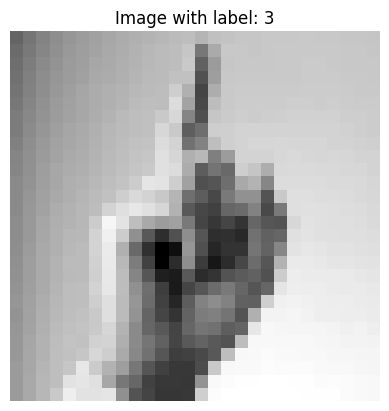

In [11]:
image_data = data_train.iloc[0, 1:].values
image_label = data_train.iloc[0, 0]

image = image_data.reshape(28, 28)

plt.imshow(image, cmap='gray')
plt.title(f'Image with label: {image_label}')
plt.axis('off')
plt.show()

In [12]:
class SignLanguageModel(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*3*3, out_features=output_shape)
    )

  def forward(self, x):
    return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [13]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model = SignLanguageModel(input_shape=1, hidden_units=64, output_shape=25).to(device)

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [15]:
def accuracy_fn(y_pred, y_true):
  correct = torch.eq(y_pred, y_true).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [16]:
from tqdm.auto import tqdm

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 10

train_loss_hist = []
test_loss_hist = []
train_acc_hist = []
test_acc_hist = []

for epoch in tqdm(range(epochs)):
  train_loss = 0
  train_acc = 0
  model.train()
  for batch, (X, y) in enumerate(train_loader):
    X = X.to(device)
    y = y.to(device)

    train_pred = model(X)
    loss = loss_fn(train_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(train_pred.argmax(dim=1), y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(train_loader)
  train_acc /= len(train_loader)
  train_loss_hist.append(train_loss)
  train_acc_hist.append(train_acc)

  model.eval()
  test_loss, test_acc = 0,0
  with torch.inference_mode():
    for X, y in test_loader:
      X = X.to(device)
      y = y.to(device)

      test_pred = model(X)
      test_loss += loss_fn(test_pred, y)
      test_acc += accuracy_fn(test_pred.argmax(dim=1), y)

    test_loss /= len(test_loader)
    test_acc /= len(test_loader)
    test_loss_hist.append(test_loss)
    test_acc_hist.append(test_acc)

  print(f'Epoch: {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%')

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 0.7849 | Train Acc: 81.03% | Test Loss: 0.3126 | Test Acc: 92.84%
Epoch: 1 | Train Loss: 0.0275 | Train Acc: 99.11% | Test Loss: 0.4827 | Test Acc: 85.73%
Epoch: 2 | Train Loss: 0.0172 | Train Acc: 99.47% | Test Loss: 0.1950 | Test Acc: 95.23%
Epoch: 3 | Train Loss: 0.0001 | Train Acc: 100.00% | Test Loss: 0.1969 | Test Acc: 95.41%
Epoch: 4 | Train Loss: 0.0000 | Train Acc: 100.00% | Test Loss: 0.2019 | Test Acc: 95.49%
Epoch: 5 | Train Loss: 0.0000 | Train Acc: 100.00% | Test Loss: 0.2060 | Test Acc: 95.53%
Epoch: 6 | Train Loss: 0.0000 | Train Acc: 100.00% | Test Loss: 0.2089 | Test Acc: 95.58%
Epoch: 7 | Train Loss: 0.0000 | Train Acc: 100.00% | Test Loss: 0.2122 | Test Acc: 95.66%
Epoch: 8 | Train Loss: 0.0000 | Train Acc: 100.00% | Test Loss: 0.2146 | Test Acc: 95.67%
Epoch: 9 | Train Loss: 0.0000 | Train Acc: 100.00% | Test Loss: 0.2165 | Test Acc: 95.71%


/tmp/ipykernel_7211/787176123.py:4: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(torch.tensor(train_loss_hist).cpu().detach().numpy(), label='Train')


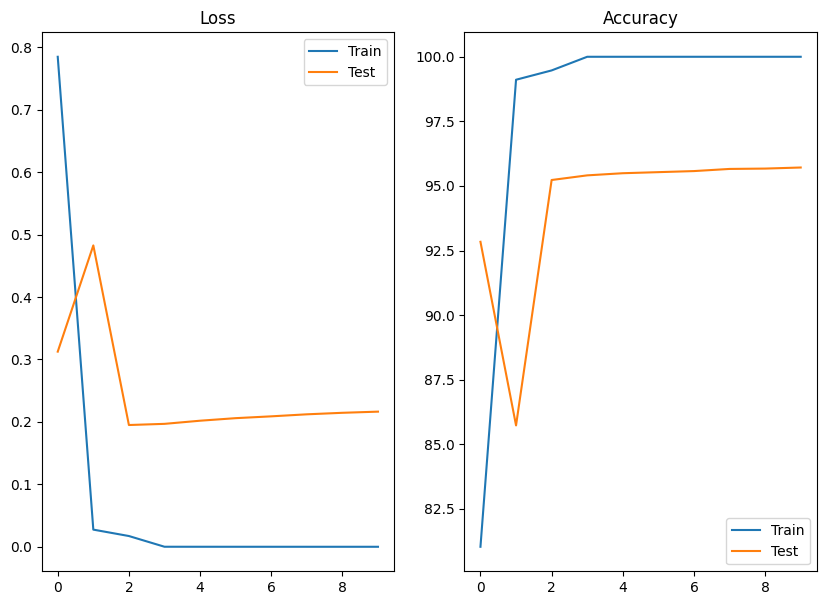

In [17]:
plt.figure(figsize=(10, 7))

plt.subplot(1, 2, 1)
plt.plot(torch.tensor(train_loss_hist).cpu().detach().numpy(), label='Train')
plt.plot(torch.tensor(test_loss_hist).cpu().detach().numpy(), label='Test')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.array(train_acc_hist), label='Train')
plt.plot(np.array(test_acc_hist), label='Test')
plt.title('Accuracy')
plt.legend()

plt.show()

In [18]:
def predict(model: torch.nn.Module, data: list, device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample, dim=0)
      pred_logits = model(sample.to(device))
      pred_prob = torch.softmax(pred_logits.squeeze(), dim=0)

      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs)

In [19]:
import random

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_dataset), k=9):
  test_samples.append(sample)
  test_labels.append(label)

pred_probs = predict(model=model, data=test_samples, device=device)

pred_classes = pred_probs.argmax(dim=1)
print(pred_classes)

tensor([ 3, 12, 13,  7,  4, 18, 22, 24, 13])


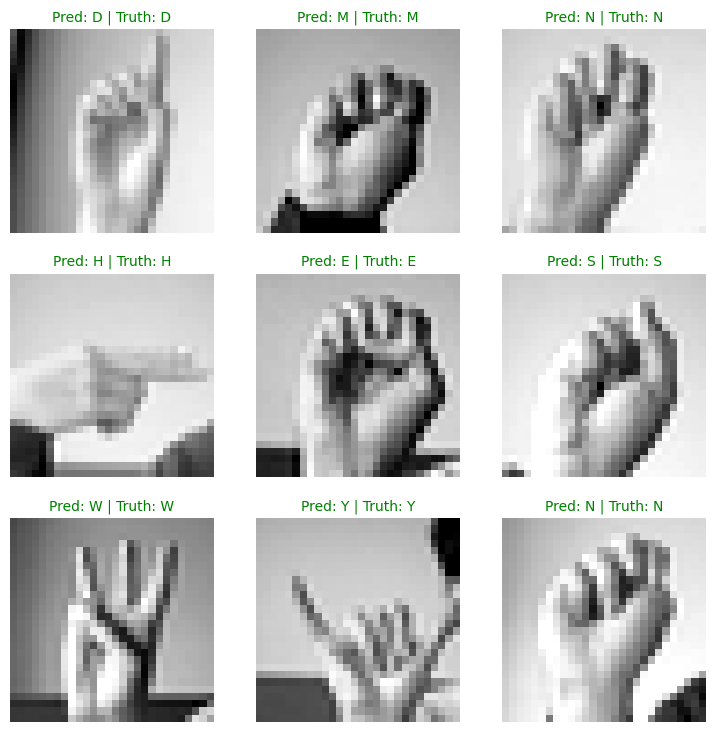

In [20]:
plt.figure(figsize=(9,9))

nrows = 3
ncols = 3

for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)

  plt.imshow(sample.squeeze(), cmap='gray')

  pred_label = label_to_char[pred_classes[i].item()]

  truth_label = label_to_char[test_labels[i].item()]
  title_text = f'Pred: {pred_label} | Truth: {truth_label}'
  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, c='g')
  else:
    plt.title(title_text, fontsize=10, c='r')
  plt.axis(False)

In [22]:
pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.8 MB/s eta 0:00:00


In [24]:
from tqdm.auto import tqdm

y_preds = []
model.eval()
with torch.inference_mode():
	for X,y in tqdm(test_loader):
		X, y = X.to(device), y.to(device)

		y_logits = model(X)
		y_pred = torch.softmax(y_logits.squeeze(), dim=0).argmax(dim=1)
		y_preds.append(y_pred.cpu())


	y_pred_tensor = torch.cat(y_preds)

  0%|          | 0/113 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/plot_confusion_matrix.py:102: RuntimeWarning: invalid value encountered in divide
  normed_conf_mat = conf_mat.astype("float") / total_samples


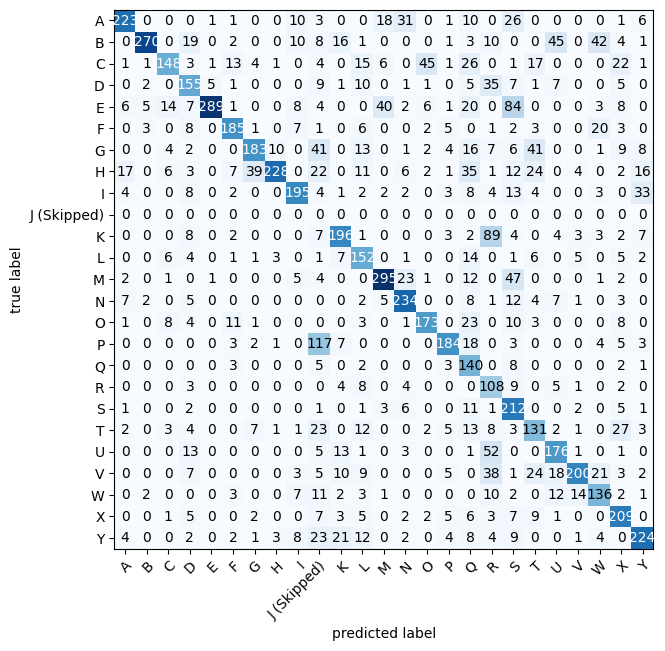

In [38]:
import mlxtend
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(task='multiclass', num_classes=25)
confmat_tensor = confmat(preds=y_pred_tensor, target=torch.from_numpy(test_dataset.labels))

display_class_names = []
for i in range(25):
    if i in label_to_char:
        display_class_names.append(label_to_char[i])
    else:
        display_class_names.append('J (Skipped)')

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names = display_class_names,
    figsize=(10,7)
)

## GitHub README.md

```markdown
# Sign Language MNIST Classification with PyTorch

## Project Overview
This project implements a Convolutional Neural Network (CNN) using PyTorch to classify images of American Sign Language (ASL) letters. The goal is to accurately identify ASL letters (excluding 'J' and 'Z', which require motion) from static images provided in the Sign Language MNIST dataset.

## Dataset
The dataset used is the Sign Language MNIST, which consists of 28x28 grayscale images of ASL letters. Each image represents a single letter (A-Y, excluding J and Z).

- **`sign_mnist_train.csv`**: Training data.
- **`sign_mnist_test.csv`**: Testing data.

## Technologies Used
- **PyTorch**: Deep learning framework for building and training the CNN model.
- **Pandas**: For data loading and manipulation (CSV files).
- **NumPy**: For numerical operations, especially with image data.
- **Matplotlib & Seaborn**: For data visualization (loss/accuracy plots, sample predictions, confusion matrix).
- **Torchvision**: For image transformations (`ToTensor`, `Normalize`).
- **Torchmetrics**: For advanced metric calculation, specifically the Confusion Matrix.
- **MLxtend**: For plotting the Confusion Matrix.

## Model Architecture
The model is a custom Convolutional Neural Network (`SignLanguageModel`) defined with:
- Two convolutional blocks, each consisting of `Conv2d` layers followed by `ReLU` activation and `MaxPool2d`.
- A `Flatten` layer to convert the 2D feature maps into a 1D vector.
- A final `Linear` layer for classification into 25 output classes (representing A-Y, with 'J' and 'Z' skipped, but preserving indices 0-24).

## Setup and Usage

1.  **Clone the Repository (or open in Google Colab)**:
    If you're viewing this as a Colab Notebook, you can run it directly. If not, clone the repository:
    ```bash
    git clone <your-repo-link>
    cd sign-language-mnist-classification
    ```

2.  **Install Dependencies**:
    ```bash
    pip install torch pandas numpy matplotlib torchvision torchmetrics mlxtend tqdm
    ```

3.  **Prepare Data**:
    Ensure `sign_mnist_train.csv` and `sign_mnist_test.csv` are in the project directory (or accessible via your Colab environment).

4.  **Run the Notebook**:
    Execute the cells in the provided Jupyter Notebook (or Google Colab notebook) sequentially. The notebook covers:
    - Data loading and preprocessing.
    - Custom `Dataset` and `DataLoader` creation.
    - Model definition.
    - Training loop (for 10 epochs).
    - Evaluation and visualization of results.

## Results
Achieved a train accuracy of 100% and a test accuracy of 95.71%.
- **Loss and Accuracy Plots**: Visualizations of training and testing loss and accuracy across epochs to observe model convergence and performance.
- **Sample Predictions**: A grid of example images from the test set, showing the model's prediction versus the true label, highlighted in green (correct) or red (incorrect).
- **Confusion Matrix**: A detailed confusion matrix showing the performance of the classifier for each ASL letter. The 'J (Skipped)' row/column indicates that this class was not part of the training data.

_Note: Due to the nature of the dataset, class 'J' (index 9) and 'Z' are not present, as they typically involve motion and are not part of static ASL image datasets._

## Future Work
- Experiment with different CNN architectures or pre-trained models.
- Implement data augmentation techniques to improve generalization.
- Explore techniques for handling class imbalance if any.
- Deploy the model as a web application for real-time sign language recognition.

```